0.336986301369863 0.43561643835616437
0.3363505800239239 0.43625215970210357


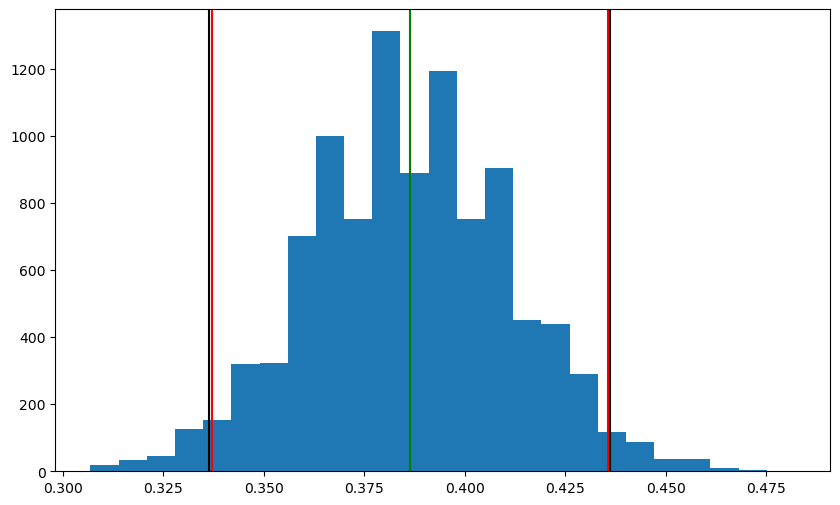

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

TRUE_P = 0.4
POP_SIZE = 20000
SAMPLE_SIZE = 200
N_BOOTSTRAP = 10000
CI_LEVEL = 0.95 # alpha = 0.05
ALPHA = 0.05

population = np.array([1] * int(TRUE_P*POP_SIZE) + [0]*int((1-TRUE_P)*POP_SIZE))
sample = np.random.choice(population, size = SAMPLE_SIZE, replace = False)
sample_p = sample.mean()
sample_s = sample.std()

meanVals = []
for _ in range(N_BOOTSTRAP):
    meanVals.append(np.random.choice(sample, size=SAMPLE_SIZE, replace = True).mean())
meanArray = np.array(meanVals)

ci_low = np.percentile(meanArray, 100*ALPHA/2)
ci_high= np.percentile(meanArray, 100 * (1- ALPHA/2))
print(ci_low, ci_high)

z = stats.norm.ppf(1-ALPHA/2)
tci_low = sample_p - z * sample_s/np.sqrt(SAMPLE_SIZE)
tci_high = sample_p + z * sample_s/np.sqrt(SAMPLE_SIZE)
print(tci_low, tci_high)

fig, ax = plt.subplots(figsize=(10,6))
ax.hist(meanArray,bins=25);
ax.axvline(ci_low, color='red')
ax.axvline(ci_high, color='red')
ax.axvline(tci_low, color='black')
ax.axvline(tci_high, color='black')
ax.axvline(sample_p, color='green')



